# 01 — Segmentation results

Analysis of the Mask R-CNN training history and the single held-out HAM10000 test evaluation. This notebook does **not** train the model or run inference again; it reads the CSV artifacts produced by `scripts/train_segmenter.py`.

Run it in the environment and machine where `results/segmentation/` exists. Generated figures and failure tables are written to `results/segmentation/analysis/`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from IPython.display import Markdown, display


def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'src' / 'scd_ml').is_dir() and (candidate / 'README.md').is_file():
            return candidate
    raise RuntimeError('Project root not found. Open this notebook from inside the scd-ml repository.')


PROJECT_ROOT = find_project_root(Path.cwd())
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from scd_ml.paths import (  # noqa: E402
    MODELS_DIR,
    SEGMENTATION_DIR,
    SEGMENTATION_EVALUATION_DIR,
    SEGMENTATION_TRAINING_DIR,
)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')

ANALYSIS_DIR = SEGMENTATION_DIR / 'analysis'
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
print(f'Project root: {PROJECT_ROOT}')
print(f'Analysis output: {ANALYSIS_DIR}')

Project root: /home/indalecio.rios/scd-ml
Analysis output: /home/indalecio.rios/scd-ml/results/segmentation/analysis


## 1. Load and validate artifacts

The three required CSV files are generated only after training finishes, the best checkpoint is restored, and the test split is evaluated. They are intentionally ignored by Git and should remain on the VM or be synchronized through object storage.

In [2]:
HISTORY_PATH = SEGMENTATION_TRAINING_DIR / 'training_history.csv'
SUMMARY_PATH = SEGMENTATION_EVALUATION_DIR / 'ham10000_test_summary.csv'
PER_IMAGE_PATH = SEGMENTATION_EVALUATION_DIR / 'ham10000_test_per_image.csv'
CHECKPOINT_PATH = MODELS_DIR / 'segmentation' / 'mask_rcnn_best.pt'
CONFIG_PATH = PROJECT_ROOT / 'configs' / 'segmentation.yaml'

required_paths = {
    'training history': HISTORY_PATH,
    'test summary': SUMMARY_PATH,
    'per-image test metrics': PER_IMAGE_PATH,
}
for label, path in required_paths.items():
    print(f'{label:24s} {"OK" if path.is_file() else "MISSING":7s} {path}')
print(f'{"best checkpoint":24s} {"OK" if CHECKPOINT_PATH.is_file() else "MISSING":7s} {CHECKPOINT_PATH}')

missing = [path for path in required_paths.values() if not path.is_file()]
if missing:
    formatted = '\n'.join(f'  - {path}' for path in missing)
    raise FileNotFoundError(
        'Training result CSVs were not found:\n'
        f'{formatted}\n\n'
        'Run this notebook on the VM that produced the results, or copy the results/segmentation directory. '
        'If training did not complete, run scripts/evaluate_segmenter.py to regenerate the test CSVs.'
    )

training history         OK      /home/indalecio.rios/scd-ml/results/segmentation/training/training_history.csv
test summary             OK      /home/indalecio.rios/scd-ml/results/segmentation/evaluation/ham10000_test_summary.csv
per-image test metrics   OK      /home/indalecio.rios/scd-ml/results/segmentation/evaluation/ham10000_test_per_image.csv
best checkpoint          OK      /home/indalecio.rios/scd-ml/models/segmentation/mask_rcnn_best.pt


In [3]:
history = pd.read_csv(HISTORY_PATH)
test_summary = pd.read_csv(SUMMARY_PATH)
per_image = pd.read_csv(PER_IMAGE_PATH)
with CONFIG_PATH.open(encoding='utf-8') as handle:
    config = yaml.safe_load(handle)

required_columns = {
    'history': {'epoch', 'train_loss', 'learning_rate', 'val_dice'},
    'test_summary': {'metric', 'macro_mean', 'macro_std', 'micro_value'},
    'per_image': {
        'image_id', 'score', 'num_detections', 'status',
        'tp', 'fp', 'fn', 'tn', 'dice', 'iou', 'precision', 'recall',
        'specificity', 'accuracy',
    },
}
for name, (frame, expected) in {
    'history': (history, required_columns['history']),
    'test_summary': (test_summary, required_columns['test_summary']),
    'per_image': (per_image, required_columns['per_image']),
}.items():
    missing_columns = sorted(expected - set(frame.columns))
    if missing_columns:
        raise ValueError(f'{name} is missing columns: {missing_columns}')
    if frame.empty:
        raise ValueError(f'{name} is empty')

numeric_columns = ['score', 'num_detections', 'tp', 'fp', 'fn', 'tn',
                   'dice', 'iou', 'precision', 'recall', 'specificity', 'accuracy']
for column in numeric_columns:
    per_image[column] = pd.to_numeric(per_image[column], errors='raise')

if per_image['image_id'].duplicated().any():
    duplicates = per_image.loc[per_image['image_id'].duplicated(False), 'image_id'].tolist()[:10]
    raise ValueError(f'Duplicate image_id values in test metrics: {duplicates}')

metric_columns = ['dice', 'iou', 'precision', 'recall', 'specificity', 'accuracy']
out_of_range = ~per_image[metric_columns].apply(lambda column: column.between(0, 1)).all(axis=1)
if out_of_range.any():
    raise ValueError(f'{int(out_of_range.sum())} rows contain metrics outside [0, 1]')

print(f'History: {len(history):,} epochs')
print(f'Test:    {len(per_image):,} unique images')
display(test_summary.style.format({
    'macro_mean': '{:.4f}', 'macro_std': '{:.4f}', 'micro_value': '{:.4f}'
}))

History: 38 epochs
Test:    2,024 unique images


,metric,macro_mean,macro_std,micro_value
0,dice,0.9433,0.0876,0.9433
1,iou,0.9018,0.1133,0.8927
2,precision,0.9466,0.0961,0.9435
3,recall,0.9501,0.0890,0.9432
4,specificity,0.9747,0.0599,0.9795
5,accuracy,0.9699,0.0526,0.9699


## 2. Training behavior

The selected epoch is the maximum validation Dice. Test metrics are not used here, so the held-out test set remains isolated from model selection.

In [4]:
best_index = history['val_dice'].idxmax()
best_row = history.loc[best_index]
best_epoch = int(best_row['epoch'])
configured_epochs = int(config['epochs'])
stopped_early = int(history['epoch'].max()) < configured_epochs

training_overview = pd.DataFrame({
    'value': {
        'epochs_completed': int(history['epoch'].max()),
        'epochs_configured': configured_epochs,
        'stopped_early': stopped_early,
        'best_epoch': best_epoch,
        'best_val_dice': float(best_row['val_dice']),
        'final_train_loss': float(history.iloc[-1]['train_loss']),
        'checkpoint_exists': CHECKPOINT_PATH.is_file(),
    }
})
display(training_overview)

if best_epoch == int(history.iloc[-1]['epoch']):
    display(Markdown('**Observation:** the best validation Dice occurred in the final executed epoch.'))
else:
    gap = int(history.iloc[-1]['epoch']) - best_epoch
    display(Markdown(f'**Observation:** the restored checkpoint precedes the final epoch by {gap} epoch(s).'))

,value
epochs_completed,38
epochs_configured,50
stopped_early,True
best_epoch,28
best_val_dice,0.9409
final_train_loss,0.1189
checkpoint_exists,True


**Observation:** the restored checkpoint precedes the final epoch by 10 epoch(s).

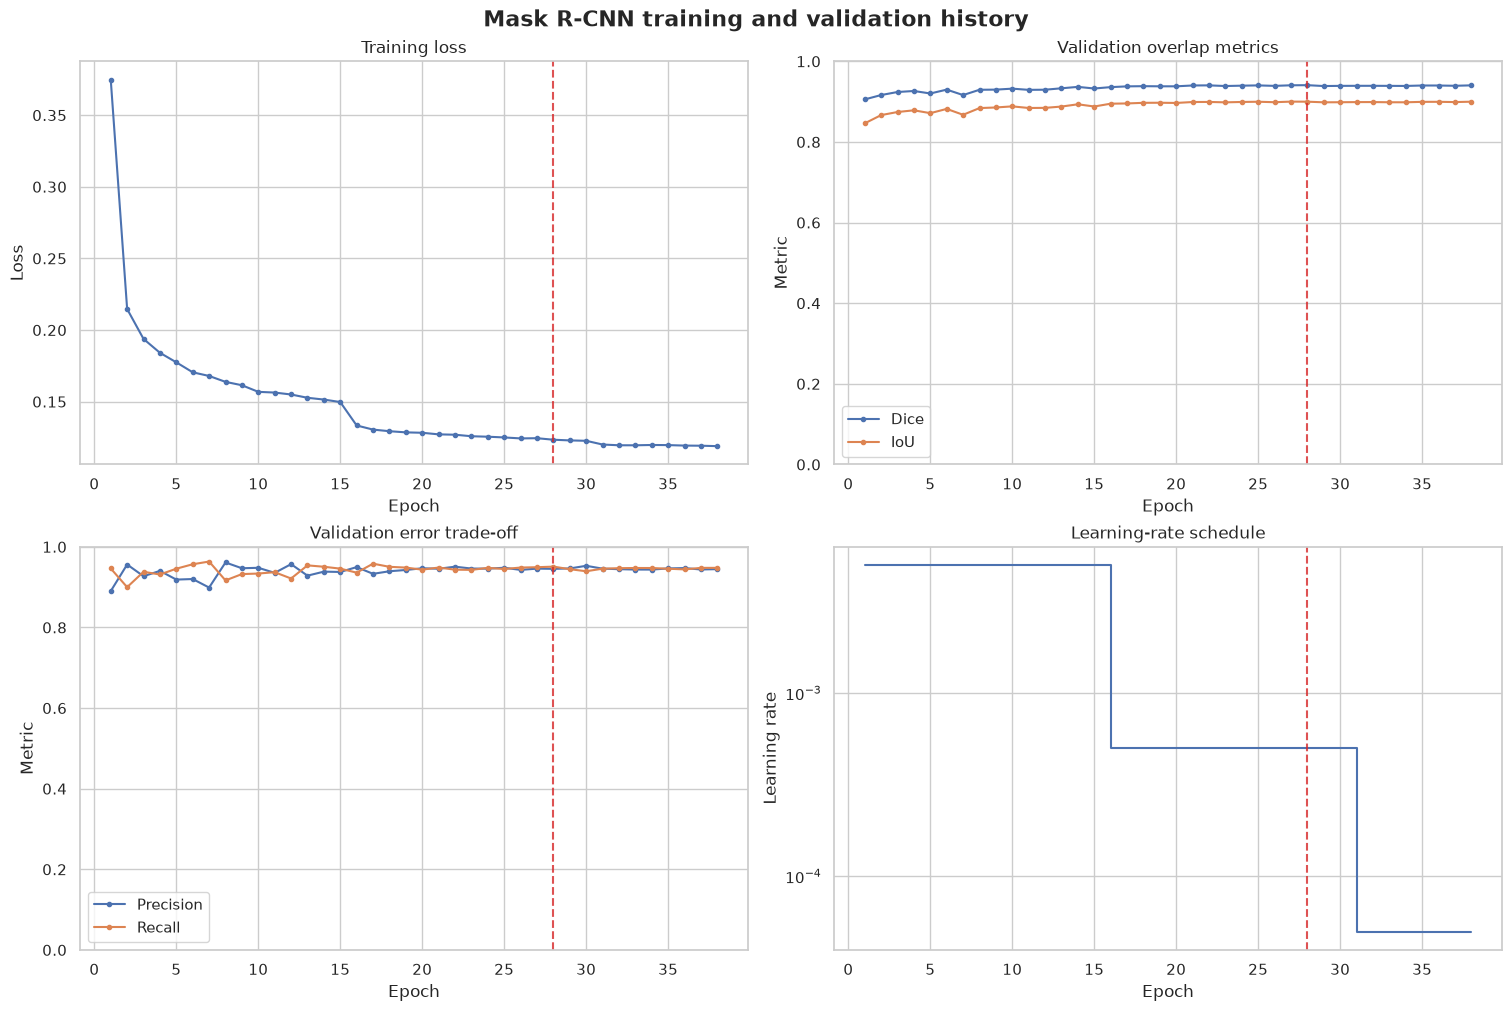

Saved: /home/indalecio.rios/scd-ml/results/segmentation/analysis/01_training_curves.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)

axes[0, 0].plot(history['epoch'], history['train_loss'], marker='o', markersize=3)
axes[0, 0].set(title='Training loss', xlabel='Epoch', ylabel='Loss')

for column, label in [('val_dice', 'Dice'), ('val_iou', 'IoU')]:
    if column in history:
        axes[0, 1].plot(history['epoch'], history[column], marker='o', markersize=3, label=label)
axes[0, 1].set(title='Validation overlap metrics', xlabel='Epoch', ylabel='Metric', ylim=(0, 1))
axes[0, 1].legend()

for column, label in [('val_precision', 'Precision'), ('val_recall', 'Recall')]:
    if column in history:
        axes[1, 0].plot(history['epoch'], history[column], marker='o', markersize=3, label=label)
axes[1, 0].set(title='Validation error trade-off', xlabel='Epoch', ylabel='Metric', ylim=(0, 1))
axes[1, 0].legend()

axes[1, 1].step(history['epoch'], history['learning_rate'], where='post')
axes[1, 1].set(title='Learning-rate schedule', xlabel='Epoch', ylabel='Learning rate')
axes[1, 1].set_yscale('log')

for axis in axes.flat:
    axis.axvline(best_epoch, color='tab:red', linestyle='--', alpha=0.8, label='Best epoch')

fig.suptitle('Mask R-CNN training and validation history', fontsize=16, fontweight='bold')
curve_path = ANALYSIS_DIR / '01_training_curves.png'
fig.savefig(curve_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {curve_path}')

## 3. Held-out test metrics and consistency audit

Macro values weight every image equally. Micro values aggregate all pixels first, so large lesions/images can have more influence. Both views should be reported.

In [6]:
METRICS = ['dice', 'iou', 'precision', 'recall', 'specificity', 'accuracy']


def safe_ratio(numerator: int, denominator: int, zero_value: float) -> float:
    return float(numerator / denominator) if denominator else zero_value


totals = per_image[['tp', 'fp', 'fn', 'tn']].sum().astype(int)
tp, fp, fn, tn = (int(totals[name]) for name in ['tp', 'fp', 'fn', 'tn'])
both_empty = tp == fp == fn == 0
micro_recomputed = {
    'dice': safe_ratio(2 * tp, 2 * tp + fp + fn, float(both_empty)),
    'iou': safe_ratio(tp, tp + fp + fn, float(both_empty)),
    'precision': safe_ratio(tp, tp + fp, 0.0),
    'recall': safe_ratio(tp, tp + fn, 0.0),
    'specificity': safe_ratio(tn, tn + fp, 0.0),
    'accuracy': safe_ratio(tp + tn, tp + tn + fp + fn, 0.0),
}

recomputed = pd.DataFrame({
    'metric': METRICS,
    'macro_mean_recomputed': [per_image[name].mean() for name in METRICS],
    'macro_std_recomputed': [per_image[name].std(ddof=0) for name in METRICS],
    'micro_value_recomputed': [micro_recomputed[name] for name in METRICS],
})
audit = test_summary.merge(recomputed, on='metric', how='outer', validate='one_to_one')
for original, recalculated in [
    ('macro_mean', 'macro_mean_recomputed'),
    ('macro_std', 'macro_std_recomputed'),
    ('micro_value', 'micro_value_recomputed'),
]:
    audit[f'{original}_abs_error'] = (audit[original] - audit[recalculated]).abs()

max_error = audit.filter(like='_abs_error').to_numpy().max()
display(audit.style.format(precision=6))
if max_error > 1e-9:
    raise AssertionError(f'Saved summary does not match per-image metrics; max error={max_error:.3e}')
print('Consistency audit passed: saved summary matches per-image recomputation.')

,metric,macro_mean,macro_std,micro_value,macro_mean_recomputed,macro_std_recomputed,micro_value_recomputed,macro_mean_abs_error,macro_std_abs_error,micro_value_abs_error
0,accuracy,0.969874,0.052563,0.969874,0.969874,0.052563,0.969874,0.000000,0.000000,0.000000
1,dice,0.943276,0.087599,0.943319,0.943276,0.087599,0.943319,0.000000,0.000000,0.000000
2,iou,0.901787,0.113258,0.892719,0.901787,0.113258,0.892719,0.000000,0.000000,0.000000
3,precision,0.946573,0.096081,0.943468,0.946573,0.096081,0.943468,0.000000,0.000000,0.000000
4,recall,0.950091,0.088969,0.943170,0.950091,0.088969,0.943170,0.000000,0.000000,0.000000
5,specificity,0.974682,0.059925,0.979541,0.974682,0.059925,0.979541,0.000000,0.000000,0.000000


Consistency audit passed: saved summary matches per-image recomputation.


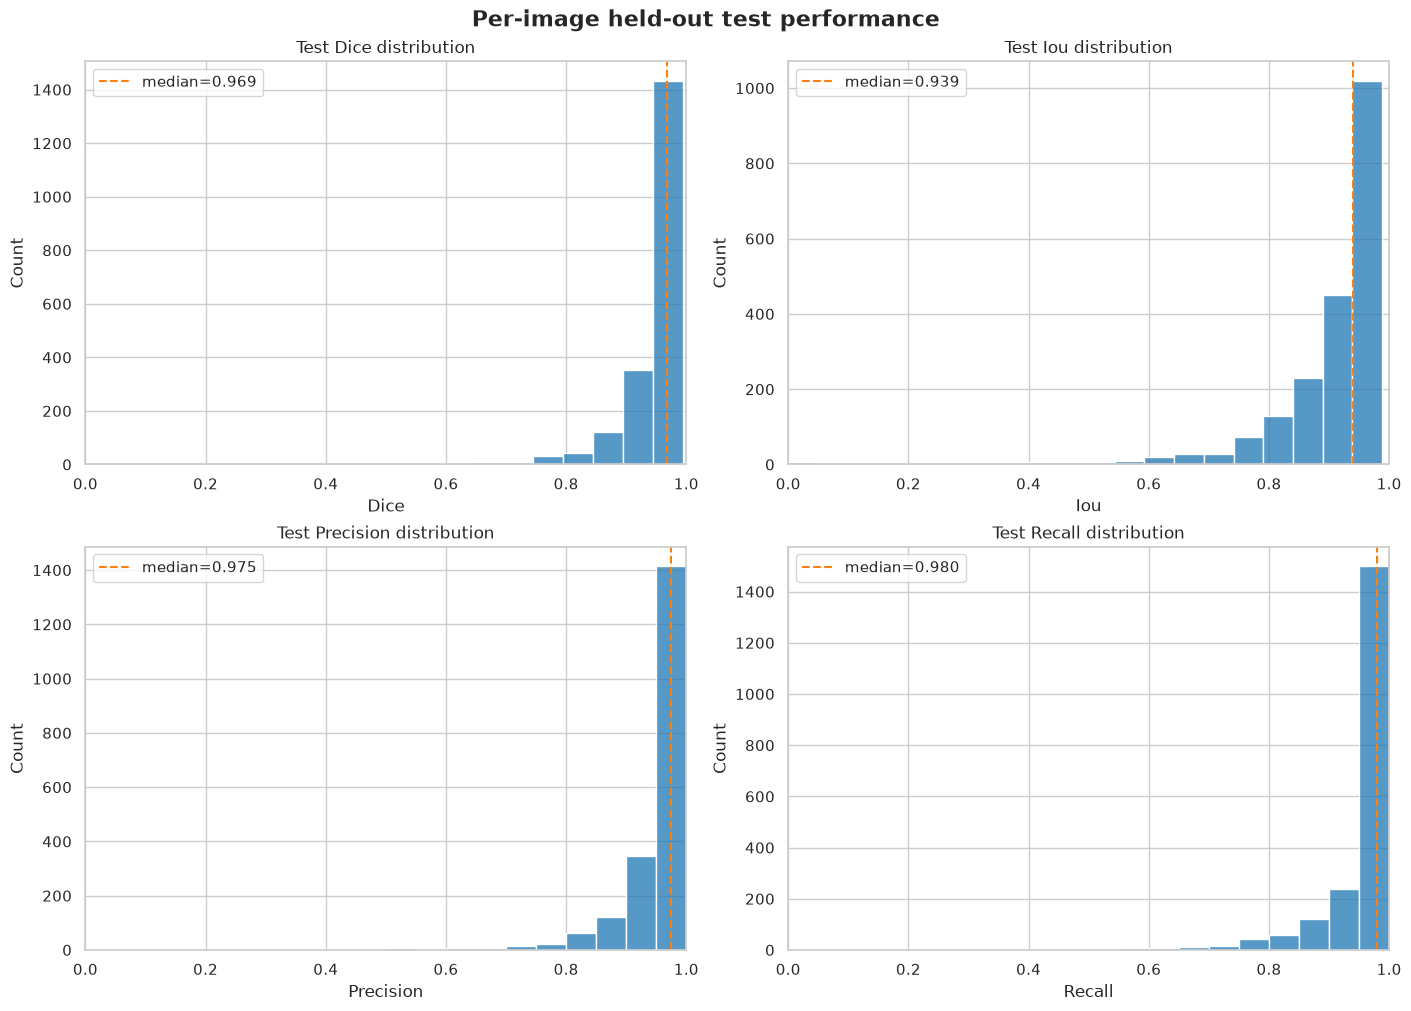

Saved: /home/indalecio.rios/scd-ml/results/segmentation/analysis/02_test_metric_distributions.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
for axis, metric in zip(axes.flat, ['dice', 'iou', 'precision', 'recall']):
    sns.histplot(per_image, x=metric, bins=20, ax=axis, color='tab:blue')
    axis.axvline(per_image[metric].median(), color='tab:orange', linestyle='--',
                 label=f'median={per_image[metric].median():.3f}')
    axis.set(title=f'Test {metric.title()} distribution', xlabel=metric.title(), xlim=(0, 1))
    axis.legend()
fig.suptitle('Per-image held-out test performance', fontsize=16, fontweight='bold')
distribution_path = ANALYSIS_DIR / '02_test_metric_distributions.png'
fig.savefig(distribution_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {distribution_path}')

## 4. Detection diagnostics

A `no_detection` row means no instance passed `score_threshold=0.5`. Its predicted mask is empty and precision is correctly defined as zero. `num_detections` counts candidates above the score threshold; only the highest-scoring candidate is used to calculate the pixel metrics.

,status,images,percentage
0,detected,2021,99.85%
1,no_detection,3,0.15%


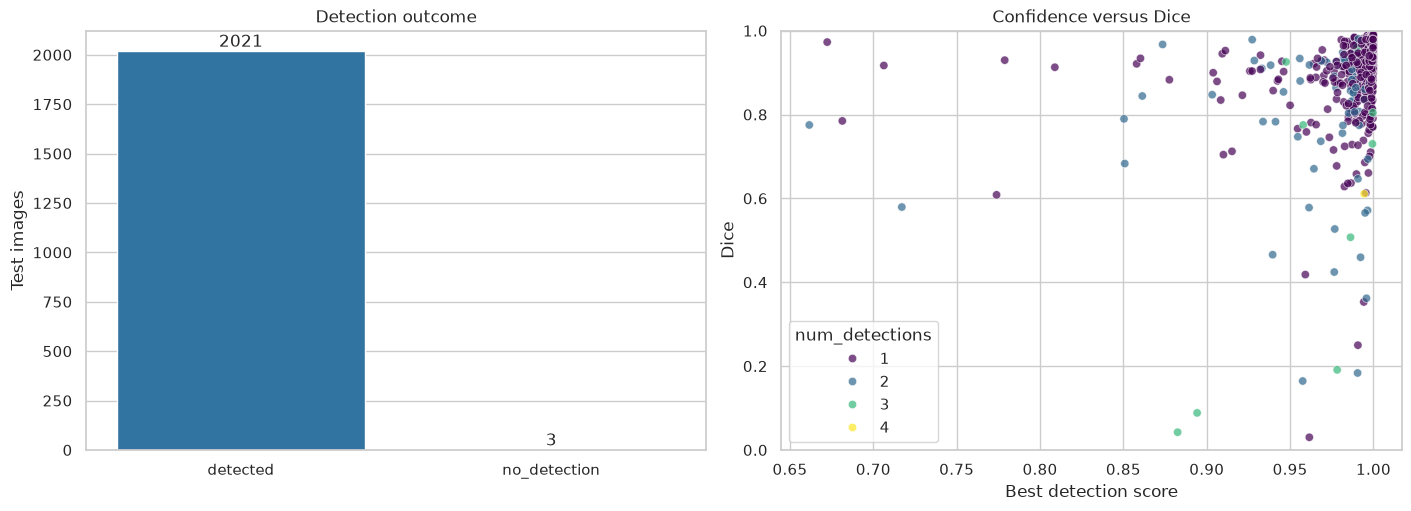

Saved: /home/indalecio.rios/scd-ml/results/segmentation/analysis/03_detection_diagnostics.png


In [8]:
status_counts = (
    per_image['status']
    .value_counts(dropna=False)
    .rename_axis('status')
    .reset_index(name='images')
)
status_counts['percentage'] = status_counts['images'] / len(per_image) * 100
display(status_counts.style.format({'percentage': '{:.2f}%'}))

invalid_status = (
    ((per_image['status'] == 'no_detection') & (per_image['num_detections'] != 0))
    | ((per_image['status'] == 'detected') & (per_image['num_detections'] < 1))
)
if invalid_status.any():
    raise AssertionError(f'{int(invalid_status.sum())} rows have inconsistent status/num_detections')

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
sns.barplot(status_counts, x='status', y='images', ax=axes[0], color='tab:blue')
axes[0].set(title='Detection outcome', xlabel='', ylabel='Test images')
for container in axes[0].containers:
    axes[0].bar_label(container)

detected = per_image.loc[per_image['status'] == 'detected'].copy()
if detected.empty:
    axes[1].text(0.5, 0.5, 'No detected cases', ha='center', va='center')
else:
    sns.scatterplot(detected, x='score', y='dice', hue='num_detections',
                    palette='viridis', alpha=0.7, ax=axes[1])
axes[1].set(title='Confidence versus Dice', xlabel='Best detection score', ylabel='Dice', ylim=(0, 1))
diagnostics_path = ANALYSIS_DIR / '03_detection_diagnostics.png'
fig.savefig(diagnostics_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {diagnostics_path}')

## 5. Failure analysis

The tables below identify cases for visual review. They do not change the model-selection decision. Because the evaluation CSV stores metrics rather than predicted masks, overlay inspection would require a separate inference/export step.

In [9]:
failure_columns = [
    'image_id', 'status', 'score', 'num_detections',
    'dice', 'iou', 'precision', 'recall', 'tp', 'fp', 'fn',
]
worst_cases = (
    per_image[failure_columns]
    .sort_values(['dice', 'iou', 'fn', 'fp'], ascending=[True, True, False, False])
    .head(25)
)
no_detection_cases = (
    per_image.loc[per_image['status'] == 'no_detection', failure_columns]
    .sort_values(['fn', 'dice'], ascending=[False, True])
)

display(Markdown('### 25 lowest-Dice cases'))
display(worst_cases.style.format({
    'score': '{:.4f}', 'dice': '{:.4f}', 'iou': '{:.4f}',
    'precision': '{:.4f}', 'recall': '{:.4f}',
}, na_rep='—'))
display(Markdown(f'### No-detection cases ({len(no_detection_cases):,})'))
display(no_detection_cases.head(25).style.format({
    'score': '{:.4f}', 'dice': '{:.4f}', 'iou': '{:.4f}',
    'precision': '{:.4f}', 'recall': '{:.4f}',
}, na_rep='—'))

worst_path = ANALYSIS_DIR / 'worst_test_cases.csv'
no_detection_path = ANALYSIS_DIR / 'no_detection_test_cases.csv'
worst_cases.to_csv(worst_path, index=False)
no_detection_cases.to_csv(no_detection_path, index=False)
print(f'Saved: {worst_path}')
print(f'Saved: {no_detection_path}')

### 25 lowest-Dice cases

,image_id,status,score,num_detections,dice,iou,precision,recall,tp,fp,fn
298,ISIC_0025903,no_detection,—,0,0.0000,0.0000,0.0000,0.0000,0,0,67289
1054,ISIC_0029505,no_detection,—,0,0.0000,0.0000,0.0000,0.0000,0,0,8852
110,ISIC_0024915,no_detection,—,0,0.0000,0.0000,0.0000,0.0000,0,0,4952
226,ISIC_0025526,detected,0.9615,1,0.0303,0.0154,0.0154,1.0000,3305,211849,0
1657,ISIC_0032694,detected,0.8825,3,0.0424,0.0216,0.0740,0.0297,817,10229,26705
168,ISIC_0025250,detected,0.8942,3,0.0884,0.0463,0.0463,1.0000,9295,191636,0
1048,ISIC_0029476,detected,0.9575,2,0.1644,0.0896,0.0896,1.0000,18334,186338,0
502,ISIC_0026829,detected,0.9905,2,0.1836,0.1011,1.0000,0.1011,4187,0,37231
171,ISIC_0025266,detected,0.9782,3,0.1911,0.1056,0.1056,1.0000,14567,123342,0
462,ISIC_0026646,detected,0.9906,1,0.2499,0.1428,0.1573,0.6075,10283,55083,6645


### No-detection cases (3)

,image_id,status,score,num_detections,dice,iou,precision,recall,tp,fp,fn
298,ISIC_0025903,no_detection,—,0,0.0000,0.0000,0.0000,0.0000,0,0,67289
1054,ISIC_0029505,no_detection,—,0,0.0000,0.0000,0.0000,0.0000,0,0,8852
110,ISIC_0024915,no_detection,—,0,0.0000,0.0000,0.0000,0.0000,0,0,4952


Saved: /home/indalecio.rios/scd-ml/results/segmentation/analysis/worst_test_cases.csv
Saved: /home/indalecio.rios/scd-ml/results/segmentation/analysis/no_detection_test_cases.csv


## Interpretation checklist

Before using this checkpoint to segment ISIC:

1. Confirm that the validation Dice curve is stable and the best epoch is not an isolated spike.
2. Report both macro and micro test Dice/IoU; a large gap signals heterogeneous image-level performance.
3. Review the no-detection rate and the lowest-Dice cases before accepting the fixed score threshold.
4. Treat this HAM10000 test evaluation as final: do not tune thresholds or architecture against it.
5. Evaluate domain shift separately after segmenting ISIC; HAM10000 performance does not establish ISIC performance.